# Análise de ERD (Event-Related Desynchronization)

Este notebook processa arquivos de dados EEG (formato OpenBCI CSV), filtra os dados na banda de 8-30 Hz, aplica a transformada de Hilbert para extrair o envelope e calcula a potência e o ERD para eventos T1 (mão esquerda) e T2 (mão direita).

A análise é restrita aos arquivos de "Run" com número par (ex: R04, R08, etc.).

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert

# Configurações
DATA_ROOT = r'C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data'
FS = 125.0  # Frequência de amostragem do OpenBCI
LOWCUT = 8.0
HIGHCUT = 30.0
ORDER = 4

# Intervalo de época (em segundos) em torno do evento
T_PRE = 2.0
T_POST = 4.0
BASELINE_WINDOW = (-1.5, -0.5)  # Segundos antes do evento para baseline

# Canais EEG (OpenBCI Cyton+Daisy tem 16 canais)
CHANNELS = [f'EXG Channel {i}' for i in range(16)]

In [2]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y

def get_envelope(data):
    analytic_signal = hilbert(data, axis=0)
    amplitude_envelope = np.abs(analytic_signal)
    return amplitude_envelope

def find_files(root_dir):
    # Procura recursivamente por arquivos CSV
    all_files = glob.glob(os.path.join(root_dir, '**', '*_csv_openbci.csv'), recursive=True)
    
    # Filtra apenas os que terminam em número par no identificador de Run (ex: R04)
    # Padrão esperado: SxxxRxx_csv_openbci.csv
    valid_files = []
    pattern = re.compile(r'R(\d+)_csv_openbci\.csv$')
    
    for f in all_files:
        match = pattern.search(f)
        if match:
            run_num = int(match.group(1))
            if run_num % 2 == 0:
                valid_files.append(f)
    
    return valid_files

def load_and_process_file(filepath):
    print(f"Processando: {filepath}")
    
    # Carregar CSV, ignorando linhas de comentário (%)
    # O cabeçalho está na linha que não começa com %
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    header_line = 0
    for i, line in enumerate(lines):
        if not line.startswith('%'):
            header_line = i
            break
            
    df = pd.read_csv(filepath, skiprows=header_line)
    
    # Extrair dados EEG
    eeg_data = df[CHANNELS].values
    
    # Filtrar 8-30 Hz
    eeg_filtered = butter_bandpass_filter(eeg_data, LOWCUT, HIGHCUT, FS, ORDER)
    
    # Envelope (Hilbert)
    envelope = get_envelope(eeg_filtered)
    
    # Potência (Envelope ao quadrado)
    power = envelope ** 2
    
    # Extrair marcadores
    # A coluna 'Annotations' contém strings como 'T0', 'T1', 'T2'
    # Vamos pegar os índices onde T1 ou T2 aparecem
    # Assumindo que o marcador aparece apenas no início do evento ou dura algum tempo
    # Vamos pegar a transição para T1 ou T2
    
    annotations = df['Annotations'].fillna('').values
    
    events = {'T1': [], 'T2': []}
    
    # Detectar bordas de subida dos eventos
    for i in range(1, len(annotations)):
        curr = str(annotations[i]).strip()
        prev = str(annotations[i-1]).strip()
        
        if curr in ['T1', 'T2'] and curr != prev:
            events[curr].append(i)
            
    return power, events

def extract_epochs(power_data, event_indices):
    epochs = []
    n_samples = len(power_data)
    n_pre = int(T_PRE * FS)
    n_post = int(T_POST * FS)
    
    for idx in event_indices:
        start = idx - n_pre
        end = idx + n_post
        
        if start >= 0 and end < n_samples:
            epochs.append(power_data[start:end, :])
            
    return np.array(epochs)

def calculate_erd(epochs):
    if len(epochs) == 0:
        return None, None
        
    # Média das épocas (trials)
    # Shape: (n_samples_epoch, n_channels)
    avg_power = np.mean(epochs, axis=0)
    
    # Calcular baseline
    n_pre = int(T_PRE * FS)
    base_start = n_pre + int(BASELINE_WINDOW[0] * FS)
    base_end = n_pre + int(BASELINE_WINDOW[1] * FS)
    
    # Baseline médio por canal
    baseline = np.mean(avg_power[base_start:base_end, :], axis=0)
    
    # ERD em dB
    # Evitar divisão por zero
    baseline[baseline == 0] = 1e-10
    erd_db = 10 * np.log10(avg_power / baseline)
    
    return erd_db, avg_power

Encontrados 172 arquivos válidos.
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04_csv_openbci.csv
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R08_csv_openbci.csv
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R12_csv_openbci.csv
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R04_csv_openbci.csv
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R08_csv_openbci.csv
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R12_csv_openbci.csv
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S

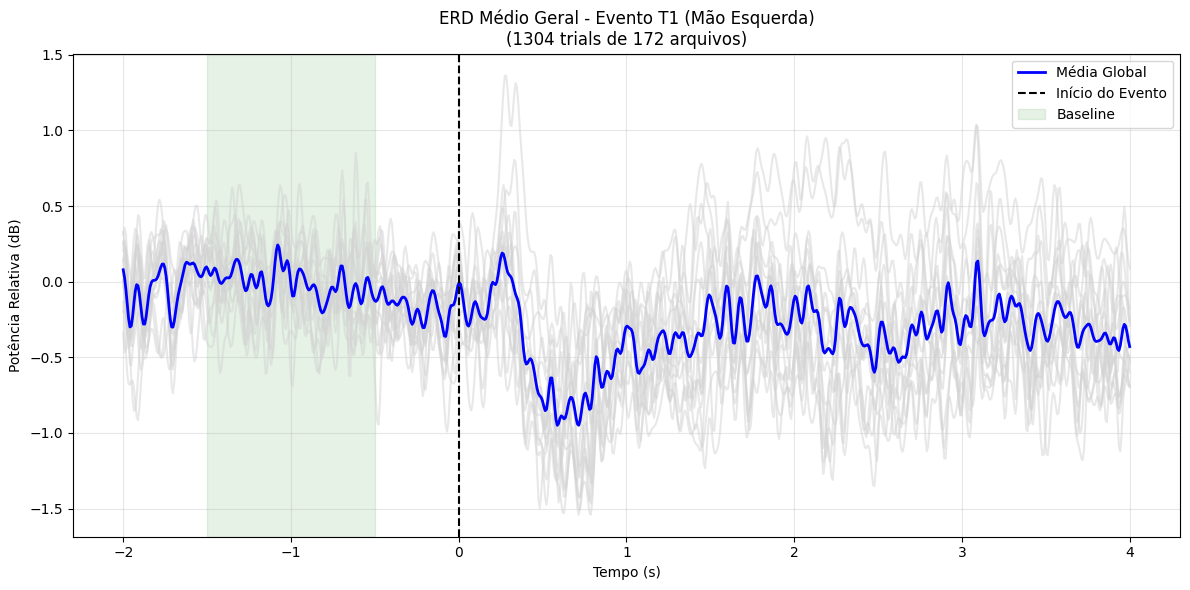

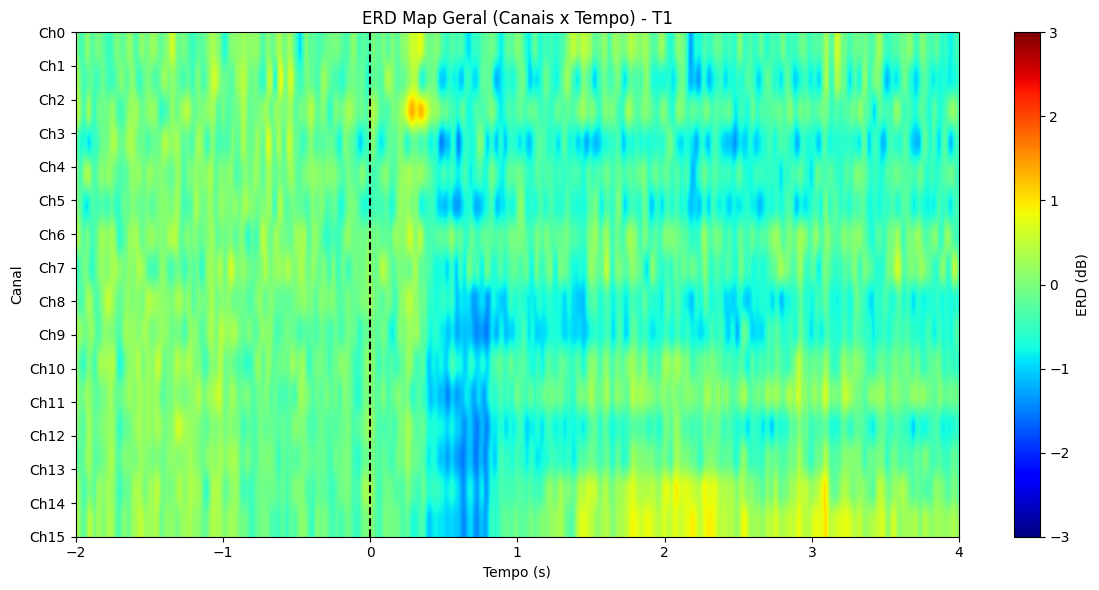

Processando T2: Total de 1276 trials acumulados.


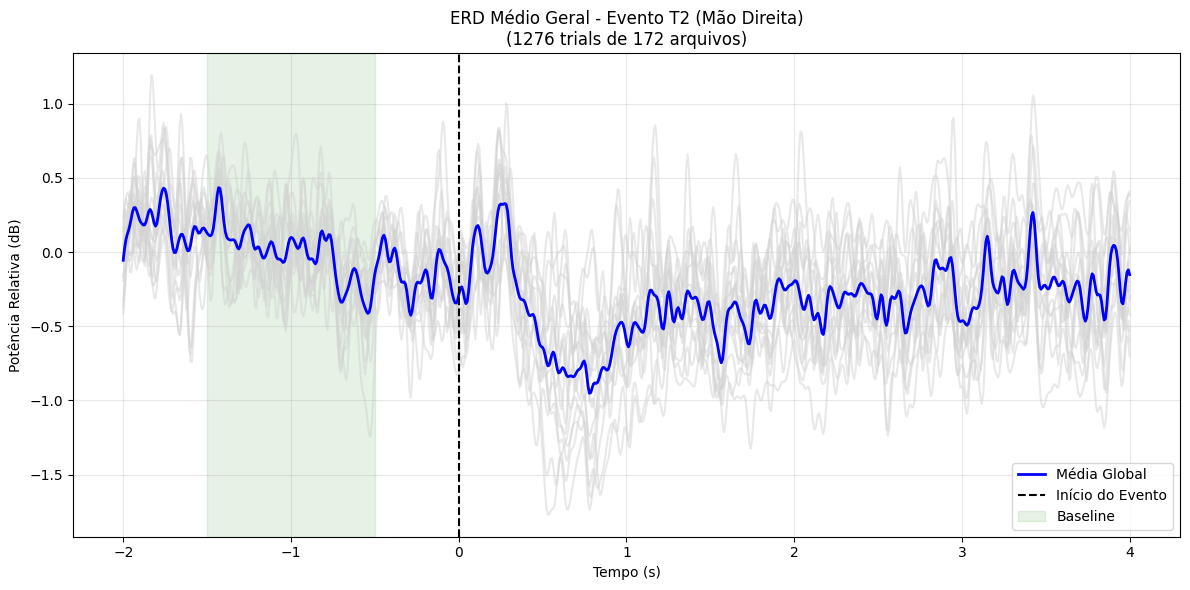

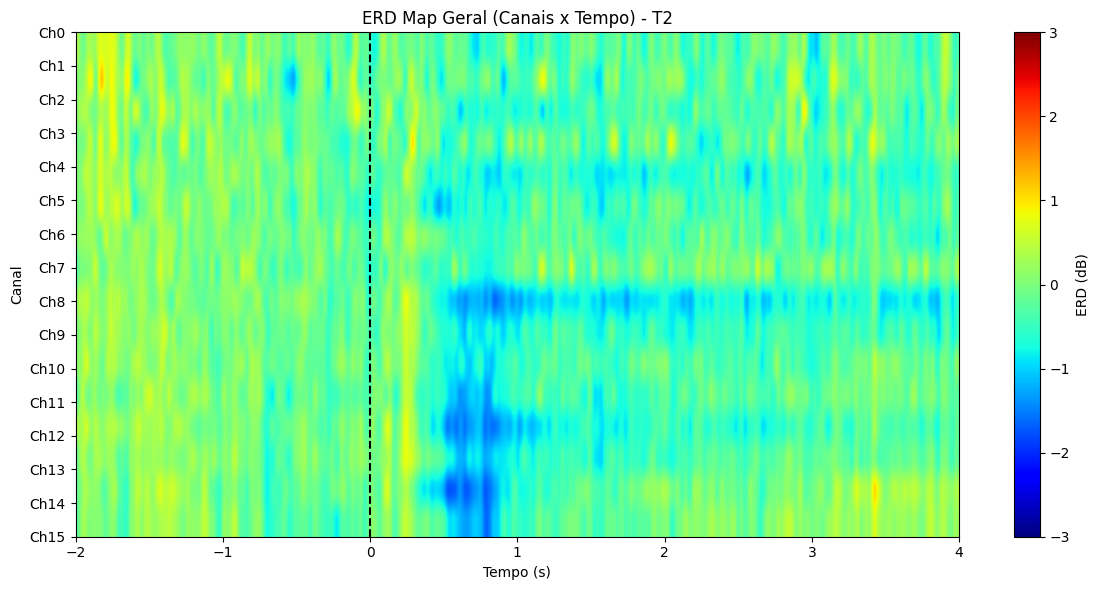

In [3]:
# Execução Principal
files = find_files(DATA_ROOT)
print(f"Encontrados {len(files)} arquivos válidos.")

all_epochs = {'T1': [], 'T2': []}

for f in files:
    try:
        power_data, events = load_and_process_file(f)
        
        for event_type in ['T1', 'T2']:
            indices = events[event_type]
            if not indices:
                continue
                
            epochs = extract_epochs(power_data, indices)
            if len(epochs) > 0:
                all_epochs[event_type].append(epochs)
    except Exception as e:
        print(f"Erro ao processar {f}: {e}")

# Processar e plotar acumulado
n_pre = int(T_PRE * FS)
n_post = int(T_POST * FS)
time_axis = np.linspace(-T_PRE, T_POST, n_pre + n_post)

for event_type in ['T1', 'T2']:
    epoch_list = all_epochs[event_type]
    
    if not epoch_list:
        print(f"Nenhum dado encontrado para {event_type}")
        continue
        
    # Concatenar todos os trials de todos os arquivos
    # epoch_list é uma lista de arrays (n_trials, n_samples, n_channels)
    combined_epochs = np.concatenate(epoch_list, axis=0)
    
    print(f"Processando {event_type}: Total de {combined_epochs.shape[0]} trials acumulados.")
    
    erd_db, avg_power = calculate_erd(combined_epochs)
    
    if erd_db is None:
        continue
        
    # Plotar
    plt.figure(figsize=(12, 6))
    
    # Plotar o ERD médio de todos os canais (linha grossa) e canais individuais (linhas finas)
    plt.plot(time_axis, erd_db, color='lightgray', alpha=0.5)
    plt.plot(time_axis, np.mean(erd_db, axis=1), color='blue', linewidth=2, label='Média Global')
    
    plt.axvline(0, color='k', linestyle='--', label='Início do Evento')
    plt.axvspan(BASELINE_WINDOW[0], BASELINE_WINDOW[1], color='green', alpha=0.1, label='Baseline')
    
    plt.title(f'ERD Médio Geral - Evento {event_type} (Mão {"Esquerda" if event_type == "T1" else "Direita"})\n({combined_epochs.shape[0]} trials de {len(files)} arquivos)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Potência Relativa (dB)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Opcional: Plotar mapa de calor (Canais x Tempo)
    plt.figure(figsize=(12, 6))
    plt.imshow(erd_db.T, aspect='auto', extent=[-T_PRE, T_POST, 15, 0], cmap='jet', vmin=-3, vmax=3)
    plt.colorbar(label='ERD (dB)')
    plt.title(f'ERD Map Geral (Canais x Tempo) - {event_type}')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Canal')
    plt.yticks(range(16), [f'Ch{i}' for i in range(16)])
    plt.axvline(0, color='k', linestyle='--')
    plt.tight_layout()
    plt.show()